# MonsoonBench: Probabilistic Model Comparison Walkthrough

This notebook demonstrates how to generate the probabilistic model comparison visualizations found in the research paper (https://arxiv.org/pdf/2602.03767). The models that are compared include IFS, FuXi-S2S, GenCast, and NGCM51. The probabilistic visualizations include:
1. Heatmaps for Brier Skill Score and AUC
2. Dual axis bar graph comparisons for Brier Skill Score, Ranked Probability Skill Score, and Area Under Curve Score
3. Reliability diagrams

Each visualization section starts with loading a base config stored in examples\configs\ which is then adjusted for each model's specific configuration (model data directory, model name, ensemble members, years, etc). This reduces the amount of code in each cell for config set-up.

## 1. Imports and Directory Set-Up

In [1]:
import copy
from pathlib import Path

import monsoonbench
from monsoonbench.visualization import (
    compare_probabilistic_models,
    create_heatmap,
    run_reliability_analysis,
)

# Find the project root dynamically
cwd = Path.cwd().resolve()
repo_root = next(
    (p for p in (cwd, *cwd.parents) if (p / "pyproject.toml").exists()), cwd
)

# Define absolute paths + create output directory
# This notebook assumes all datasets used in the paper are stored in the directory: repo_root/data
data_dir = repo_root / "data"
output_dir = repo_root / "examples/demo_notebooks/outputs"
output_dir.mkdir(parents=True, exist_ok=True)

print(f"MonsoonBench version: {monsoonbench.__version__}")
print(f"Available functions: {monsoonbench.__all__}")

MonsoonBench version: 0.1.0
Available functions: ['__version__', 'main', 'load', 'get_registered', 'register_loader', 'DeterministicOnsetMetrics', 'ProbabilisticOnsetMetrics', 'ClimatologyOnsetMetrics', 'load_config', 'plot_spatial_metrics']


## 2. BSS and AUC Heat Maps

In [2]:
heatmap_base_config = {
    # Required arguments
    # Directory containing IMD rainfall data
    "imd_folder": f"{data_dir}/imd_rainfall_data/4p0",
    # Path to IMD onset threshold file
    "thres_file": f"{data_dir}/imd_onset_threshold/mwset4x4.nc4",
    # Optional arguments with defaults
    # File pattern for model data
    "file_pattern": "{}.nc",
    # Maximum forecast day (15 or 30)
    "max_forecast_day": 30,
    # Directory to save output files
    "save_dir": output_dir,
    # Use MOK date filter (June 2nd) for onset detection
    "mok": True,
}

### IFS-S2S Model: Period 2019-2024
- Full match to paper data

S2S MONSOON ONSET SKILL SCORE ANALYSIS
Model: ifs
Years: [2019, 2020, 2021, 2022, 2023]
Max forecast day: 30
Day bins: [(1, 5), (6, 10), (11, 15), (16, 20), (21, 25), (26, 30)]
MOK filter: True (June 2nd)
Output directory: /Users/christinetsai/winter2026/aice/monsoon-bench/examples/demo_notebooks/outputs

1. Processing forecast model...
Processing years: [2019, 2020, 2021, 2022, 2023]
Using 4-degree CMZ polygon coordinates

Processing year 2019
Loading S2S model data...
Loading IMD rainfall data...
Loading IMD rainfall from: /Users/christinetsai/winter2026/aice/monsoon-bench/data/imd_rainfall_data/4p0/2019.nc
Renamed dimensions: {'TIME': 'time'}
Detecting observed onset...
Using MOK date (June 2nd) (2019-06-02) as start date for onset detection
Found onset in 100 out of 100 grid points
Computing onset for all ensemble members...
Processing 26 init times x 10 unique locations x 11 members...
Unique lat-lon pairs: [(np.float64(76.0), np.float64(20.0)), (np.float64(80.0), np.float64(20.0)

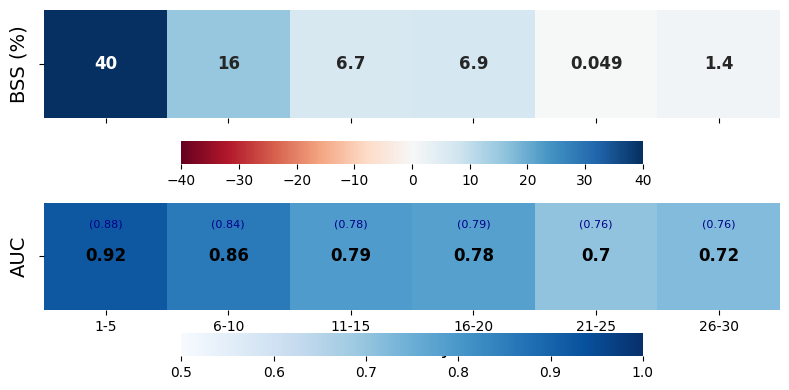

Figure saved as '/Users/christinetsai/winter2026/aice/monsoon-bench/examples/demo_notebooks/outputs/skill_scores_heatmap_ifs_30day.png'


In [13]:
model_config = {
    # Directory containing model forecast data.
    "model_forecast_dir": f"{data_dir}/model_forecast_data/IFS-S2S/tp_4p0",
    # Model name for output files
    "model_name": "ifs",
    # Number of ensemble members to use
    "mem_num": 11,
    # Years to process
    "years": [2019, 2020, 2021, 2022, 2023],
    # Year to use for date filtering
    "date_filter_year": 2024,
}
final_config = heatmap_base_config | model_config
create_heatmap(final_config)

#### IFS-S2S Model: Period 2004-2021
- Full match to paper data

S2S MONSOON ONSET SKILL SCORE ANALYSIS
Model: ifs
Years: [2004, 2005, 2006, 2007, 2008, 2009, 2010, 2011, 2012, 2013, 2014, 2015, 2016, 2017, 2018, 2019, 2020, 2021]
Max forecast day: 30
Day bins: [(1, 5), (6, 10), (11, 15), (16, 20), (21, 25), (26, 30)]
MOK filter: True (June 2nd)
Output directory: /Users/christinetsai/winter2026/aice/monsoon-bench/examples/demo_notebooks/outputs

1. Processing forecast model...
Processing years: [2004, 2005, 2006, 2007, 2008, 2009, 2010, 2011, 2012, 2013, 2014, 2015, 2016, 2017, 2018, 2019, 2020, 2021]
Using 4-degree CMZ polygon coordinates

Processing year 2004
Loading S2S model data...
Loading IMD rainfall data...
Loading IMD rainfall from: /Users/christinetsai/winter2026/aice/monsoon-bench/data/imd_rainfall_data/4p0/2004.nc
Renamed dimensions: {'TIME': 'time'}
Detecting observed onset...
Using MOK date (June 2nd) (2004-06-02) as start date for onset detection
Found onset in 100 out of 100 grid points
Computing onset for all ensemble members...
Pro

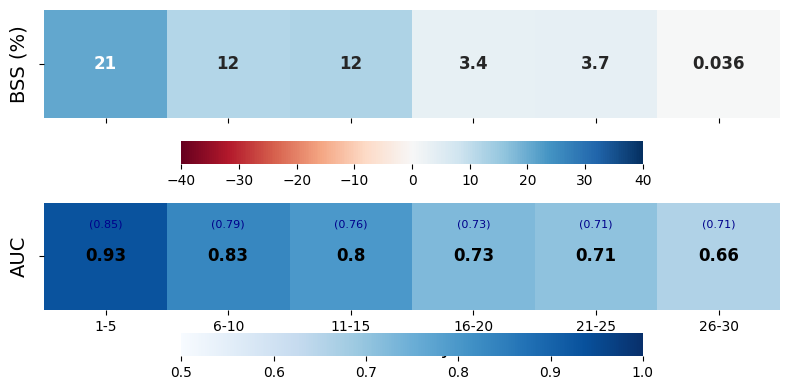

Figure saved as '/Users/christinetsai/winter2026/aice/monsoon-bench/examples/demo_notebooks/outputs/skill_scores_heatmap_ifs_30day.png'


In [14]:
model_config = {
    # Directory containing model forecast data.
    "model_forecast_dir": f"{data_dir}/model_forecast_data/IFS-S2S/tp_4p0",
    # Model name for output files
    "model_name": "ifs",
    # Number of ensemble members to use
    "mem_num": 11,
    # Years to process
    "years": [
        2004,
        2005,
        2006,
        2007,
        2008,
        2009,
        2010,
        2011,
        2012,
        2013,
        2014,
        2015,
        2016,
        2017,
        2018,
        2019,
        2020,
        2021,
    ],
    # Year to use for date filtering
    "date_filter_year": 2024,
}
final_config = heatmap_base_config | model_config
create_heatmap(final_config)

### Gencast Model: Period 2019-2024
- Full match to paper data

S2S MONSOON ONSET SKILL SCORE ANALYSIS
Model: gencast
Years: [2019, 2020, 2021, 2022, 2023, 2024]
Max forecast day: 30
Day bins: [(1, 5), (6, 10), (11, 15), (16, 20), (21, 25), (26, 30)]
MOK filter: True (June 2nd)
Output directory: /Users/christinetsai/winter2026/aice/monsoon-bench/examples/demo_notebooks/outputs

1. Processing forecast model...
Processing years: [2019, 2020, 2021, 2022, 2023, 2024]
Using 4-degree CMZ polygon coordinates

Processing year 2019
Loading S2S model data...
Loading IMD rainfall data...
Loading IMD rainfall from: /Users/christinetsai/winter2026/aice/monsoon-bench/data/imd_rainfall_data/4p0/2019.nc
Renamed dimensions: {'TIME': 'time'}
Detecting observed onset...
Using MOK date (June 2nd) (2019-06-02) as start date for onset detection
Found onset in 100 out of 100 grid points
Computing onset for all ensemble members...
Processing 26 init times x 10 unique locations x 51 members...
Unique lat-lon pairs: [(np.float64(76.0), np.float64(20.0)), (np.float64(80.0), 

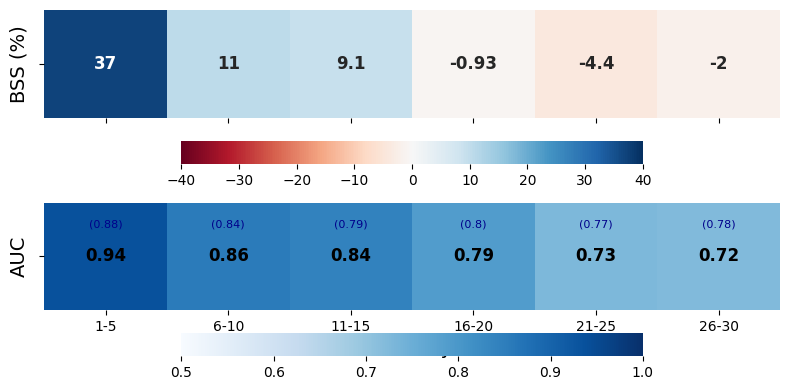

Figure saved as '/Users/christinetsai/winter2026/aice/monsoon-bench/examples/demo_notebooks/outputs/skill_scores_heatmap_gencast_30day.png'


In [ ]:
model_config = {
    # Directory containing model forecast data.
    "model_forecast_dir": f"{data_dir}/model_forecast_data/gencast52/tp_lsm_4p0",
    # Model name for output files
    "model_name": "gencast",
    # Number of ensemble members to use
    "mem_num": 51,
    # Years to process
    "years": [2019, 2020, 2021, 2022, 2023, 2024],
    # Year to use for date filtering
    "date_filter_year": 2024,
}
config = heatmap_base_config | model_config
create_heatmap(config)

### Fuxi-S2S Model: Period 2019-2024

S2S MONSOON ONSET SKILL SCORE ANALYSIS
Model: fuxi-s2s
Years: [2019, 2020, 2021]
Max forecast day: 30
Day bins: [(1, 5), (6, 10), (11, 15), (16, 20), (21, 25), (26, 30)]
MOK filter: True (June 2nd)
Output directory: /Users/christinetsai/winter2026/aice/monsoon-bench/examples/demo_notebooks/outputs

1. Processing forecast model...
Processing years: [2019, 2020, 2021]
Using 4-degree CMZ polygon coordinates

Processing year 2019
Loading S2S model data...
Loading IMD rainfall data...
Loading IMD rainfall from: /Users/christinetsai/winter2026/aice/monsoon-bench/data/imd_rainfall_data/4p0/2019.nc
Renamed dimensions: {'TIME': 'time'}
Detecting observed onset...
Using MOK date (June 2nd) (2019-06-02) as start date for onset detection
Found onset in 100 out of 100 grid points
Computing onset for all ensemble members...
Processing 26 init times x 10 unique locations x 51 members...
Unique lat-lon pairs: [(np.float64(76.0), np.float64(20.0)), (np.float64(80.0), np.float64(20.0)), (np.float64(84.0

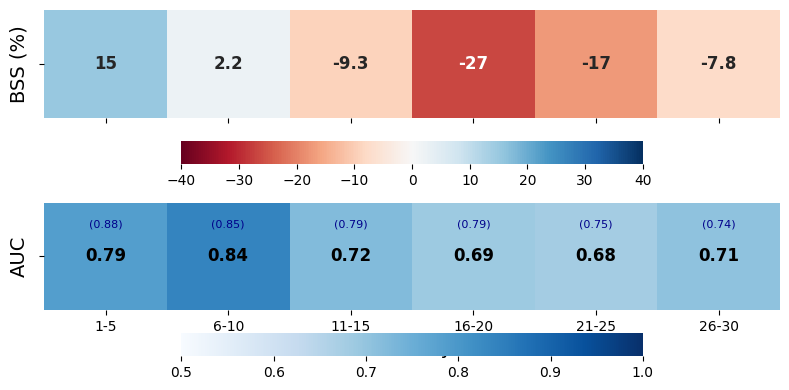

Figure saved as '/Users/christinetsai/winter2026/aice/monsoon-bench/examples/demo_notebooks/outputs/skill_scores_heatmap_fuxi-s2s_30day.png'


In [15]:
model_config = {
    # Directory containing model forecast data.
    "model_forecast_dir": f"{data_dir}/model_forecast_data/fuxi_s2s/tp_4p0",
    # Model name for output files
    "model_name": "fuxi-s2s",
    # Number of ensemble members to use
    "mem_num": 51,
    # Years to process
    "years": [2019, 2020, 2021],
    # Year to use for date filtering
    "date_filter_year": 2022,
}
config = heatmap_base_config | model_config
create_heatmap(config)

#### FuXi-S2S: Period 2004-2021
- Full match to paper data

S2S MONSOON ONSET SKILL SCORE ANALYSIS
Model: fuxi-s2s
Years: [2004, 2005, 2006, 2007, 2008, 2009, 2010, 2011, 2012, 2013, 2014, 2015, 2016, 2017, 2018, 2019, 2020, 2021]
Max forecast day: 30
Day bins: [(1, 5), (6, 10), (11, 15), (16, 20), (21, 25), (26, 30)]
MOK filter: True (June 2nd)
Output directory: /Users/christinetsai/winter2026/aice/monsoon-bench/examples/demo_notebooks/outputs

1. Processing forecast model...
Processing years: [2004, 2005, 2006, 2007, 2008, 2009, 2010, 2011, 2012, 2013, 2014, 2015, 2016, 2017, 2018, 2019, 2020, 2021]
Using 4-degree CMZ polygon coordinates

Processing year 2004
Loading S2S model data...
Loading IMD rainfall data...
Loading IMD rainfall from: /Users/christinetsai/winter2026/aice/monsoon-bench/data/imd_rainfall_data/4p0/2004.nc
Renamed dimensions: {'TIME': 'time'}
Detecting observed onset...
Using MOK date (June 2nd) (2004-06-02) as start date for onset detection
Found onset in 100 out of 100 grid points
Computing onset for all ensemble members..

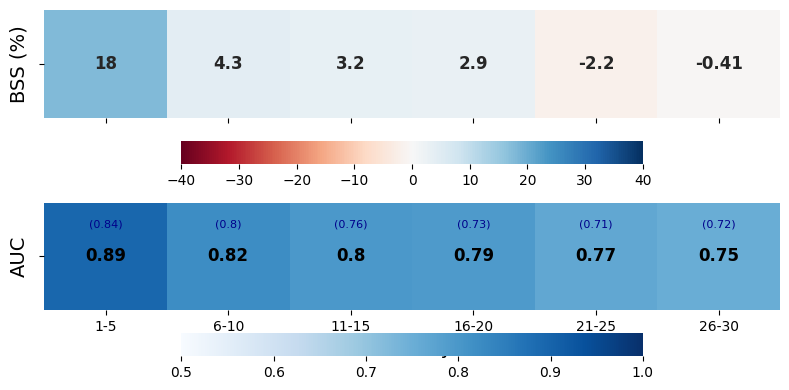

Figure saved as '/Users/christinetsai/winter2026/aice/monsoon-bench/examples/demo_notebooks/outputs/skill_scores_heatmap_fuxi-s2s_30day.png'


In [16]:
model_config = {
    # Directory containing model forecast data.
    "model_forecast_dir": f"{data_dir}/model_forecast_data/fuxi_s2s/tp_4p0",
    # Model name for output files
    "model_name": "fuxi-s2s",
    # Number of ensemble members to use
    "mem_num": 51,
    # Years to process
    "years": [
        2004,
        2005,
        2006,
        2007,
        2008,
        2009,
        2010,
        2011,
        2012,
        2013,
        2014,
        2015,
        2016,
        2017,
        2018,
        2019,
        2020,
        2021,
    ],
    # Year to use for date filtering
    "date_filter_year": 2022,
}
config = heatmap_base_config | model_config
create_heatmap(config)

### NGCM Model (Climatology): Period 2019-2024
- Full match to paper data

S2S MONSOON ONSET SKILL SCORE ANALYSIS
Model: ngcm
Years: [2019, 2020, 2021, 2022, 2023, 2024]
Max forecast day: 30
Day bins: [(1, 5), (6, 10), (11, 15), (16, 20), (21, 25), (26, 30)]
MOK filter: True (June 2nd)
Output directory: /Users/christinetsai/winter2026/aice/monsoon-bench/examples/demo_notebooks/outputs

1. Processing forecast model...
Processing years: [2019, 2020, 2021, 2022, 2023, 2024]
Using 4-degree CMZ polygon coordinates

Processing year 2019
Loading S2S model data...
Loading IMD rainfall data...
Loading IMD rainfall from: /Users/christinetsai/winter2026/aice/monsoon-bench/data/imd_rainfall_data/4p0/2019.nc
Renamed dimensions: {'TIME': 'time'}
Detecting observed onset...
Using MOK date (June 2nd) (2019-06-02) as start date for onset detection
Found onset in 100 out of 100 grid points
Computing onset for all ensemble members...
Processing 26 init times x 10 unique locations x 51 members...
Unique lat-lon pairs: [(np.float64(76.0), np.float64(20.0)), (np.float64(80.0), np.

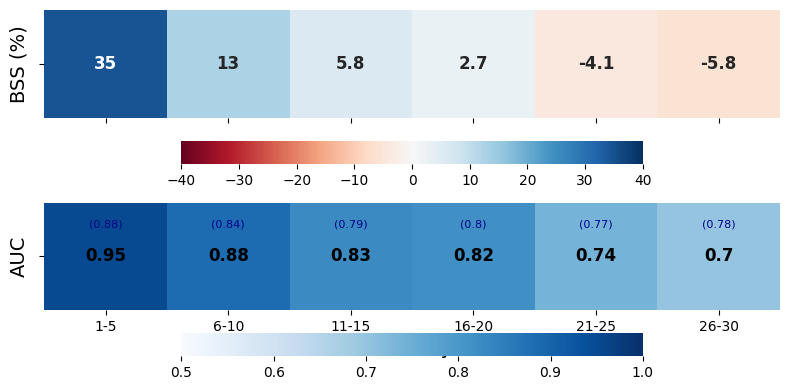

Figure saved as '/Users/christinetsai/winter2026/aice/monsoon-bench/examples/demo_notebooks/outputs/skill_scores_heatmap_ngcm_30day.png'


In [ ]:
model_config = {
    # Directory containing model forecast data.
    "model_forecast_dir": f"{data_dir}/model_forecast_data/ngcm51/climatology/tp_4p0",
    # Model name for output files
    "model_name": "ngcm",
    # Number of ensemble members to use
    "mem_num": 51,
    # Years to process
    "years": [2019, 2020, 2021, 2022, 2023, 2024],
    # Year to use for date filtering
    "date_filter_year": 2024,
}
config = heatmap_base_config | model_config
create_heatmap(config)

#### NGCM Model: Period 2004-2021
- Full match to paper data

S2S MONSOON ONSET SKILL SCORE ANALYSIS
Model: ngcm
Years: [2004, 2005, 2006, 2007, 2008, 2009, 2010, 2011, 2012, 2013, 2014, 2015, 2016, 2017, 2018, 2019, 2020, 2021]
Max forecast day: 30
Day bins: [(1, 5), (6, 10), (11, 15), (16, 20), (21, 25), (26, 30)]
MOK filter: True (June 2nd)
Output directory: /Users/christinetsai/winter2026/aice/monsoon-bench/examples/demo_notebooks/outputs

1. Processing forecast model...
Processing years: [2004, 2005, 2006, 2007, 2008, 2009, 2010, 2011, 2012, 2013, 2014, 2015, 2016, 2017, 2018, 2019, 2020, 2021]
Using 4-degree CMZ polygon coordinates

Processing year 2004
Loading S2S model data...
Loading IMD rainfall data...
Loading IMD rainfall from: /Users/christinetsai/winter2026/aice/monsoon-bench/data/imd_rainfall_data/4p0/2004.nc
Renamed dimensions: {'TIME': 'time'}
Detecting observed onset...
Using MOK date (June 2nd) (2004-06-02) as start date for onset detection
Found onset in 100 out of 100 grid points
Computing onset for all ensemble members...
Pr

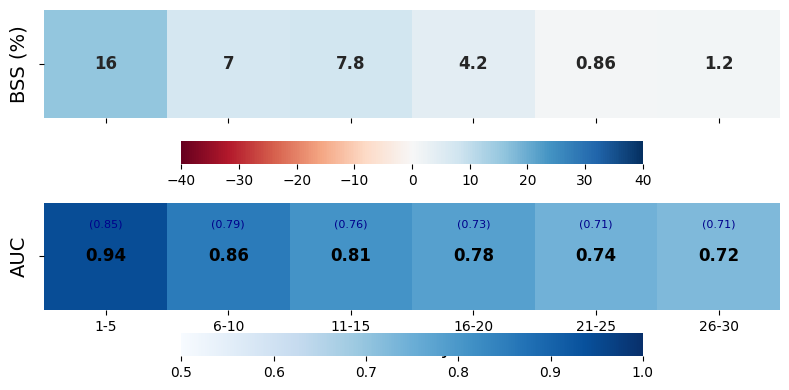

Figure saved as '/Users/christinetsai/winter2026/aice/monsoon-bench/examples/demo_notebooks/outputs/skill_scores_heatmap_ngcm_30day.png'


In [ ]:
model_config = {
    # Directory containing model forecast data.
    "model_forecast_dir": f"{data_dir}/model_forecast_data/ngcm51/climatology/tp_4p0",
    # Model name for output files
    "model_name": "ngcm",
    # Number of ensemble members to use
    "mem_num": 51,
    # Years to process
    "years": [
        2004,
        2005,
        2006,
        2007,
        2008,
        2009,
        2010,
        2011,
        2012,
        2013,
        2014,
        2015,
        2016,
        2017,
        2018,
        2019,
        2020,
        2021,
    ],
    # Year to use for date filtering
    "date_filter_year": 2024,
}
config = heatmap_base_config | model_config
create_heatmap(config)

## 3. BSS/RPSS/AUC Dual Comparison Axis Graphs

#### IFS, GenCast, FuXi-S2S, NGCM Models - Period: 2019-2024, 15 day forecast

Processing 124 years: [1901, 1902, 1903, 1904, 1905, 1906, 1907, 1908, 1909, 1910, 1911, 1912, 1913, 1914, 1915, 1916, 1917, 1918, 1919, 1920, 1921, 1922, 1923, 1924, 1925, 1926, 1927, 1928, 1929, 1930, 1931, 1932, 1933, 1934, 1935, 1936, 1937, 1938, 1939, 1940, 1941, 1942, 1943, 1944, 1945, 1946, 1947, 1948, 1949, 1950, 1951, 1952, 1953, 1954, 1955, 1956, 1957, 1958, 1959, 1960, 1961, 1962, 1963, 1964, 1965, 1966, 1967, 1968, 1969, 1970, 1971, 1972, 1973, 1974, 1975, 1976, 1977, 1978, 1979, 1980, 1981, 1982, 1983, 1984, 1985, 1986, 1987, 1988, 1989, 1990, 1991, 1992, 1993, 1994, 1995, 1996, 1997, 1998, 1999, 2000, 2001, 2002, 2003, 2004, 2005, 2006, 2007, 2008, 2009, 2010, 2011, 2012, 2013, 2014, 2015, 2016, 2017, 2018, 2019, 2020, 2021, 2022, 2023, 2024]

Processing year 1901...
Loading IMD rainfall from: /Users/christinetsai/winter2026/aice/monsoon-bench/data/imd_rainfall_data/4p0/1901.nc
Renamed dimensions: {'TIME': 'time'}
Using MOK date (June 2nd) (1901-06-02) as start date for o

Traceback (most recent call last):
  File "/Users/christinetsai/winter2026/aice/monsoon-bench/monsoonbench/metrics/probabilistic.py", line 986, in multi_year_forecast_obs_pairs
    ProbabilisticOnsetMetrics.get_forecast_probabilistic_twice_weekly_2(
    ~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~^
        year,
        ^^^^^
    ...<3 lines>...
        file_pattern,
        ^^^^^^^^^^^^^
    )
    ^
  File "/Users/christinetsai/winter2026/aice/monsoon-bench/monsoonbench/metrics/probabilistic.py", line 104, in get_forecast_probabilistic_twice_weekly_2
    raise FileNotFoundError(f"File not found: {file_path}")
FileNotFoundError: File not found: /Users/christinetsai/winter2026/aice/monsoon-bench/data/model_forecast_data/IFS-S2S/tp_4p0/2024.nc


Generated 750 climatological forecast-observation pairs
Unique lat-lon pairs processed: 10
Total bins per forecast: 5
Probability range: 0.000 - 1.000
Observed onset rate: 0.200
Non-zero probabilities: 457
Unique locations in output: 10

Distribution across bins:
                      predicted_prob        observed_onset  \
                               count   mean           mean   
bin_label                                                    
After day 15                     150  0.666          0.727   
Before initialization            150  0.109          0.000   
Days 1-5                         150  0.064          0.080   
Days 11-15                       150  0.086          0.093   
Days 6-10                        150  0.074          0.100   

                      n_contributing_years total_members_with_onset  
                                      mean                     mean  
bin_label                                                            
After day 15                 

Traceback (most recent call last):
  File "/Users/christinetsai/winter2026/aice/monsoon-bench/monsoonbench/metrics/probabilistic.py", line 986, in multi_year_forecast_obs_pairs
    ProbabilisticOnsetMetrics.get_forecast_probabilistic_twice_weekly_2(
    ~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~^
        year,
        ^^^^^
    ...<3 lines>...
        file_pattern,
        ^^^^^^^^^^^^^
    )
    ^
  File "/Users/christinetsai/winter2026/aice/monsoon-bench/monsoonbench/metrics/probabilistic.py", line 104, in get_forecast_probabilistic_twice_weekly_2
    raise FileNotFoundError(f"File not found: {file_path}")
FileNotFoundError: File not found: /Users/christinetsai/winter2026/aice/monsoon-bench/data/model_forecast_data/fuxi_s2s/tp_4p0/2022.nc
Traceback (most recent call last):
  File "/Users/christinetsai/winter2026/aice/monsoon-bench/monsoonbench/metrics/probabilistic.py", line 986, in multi_year_forecast_obs_pairs
    ProbabilisticOnsetMetrics.get_forecast_prob

Generated 750 climatological forecast-observation pairs
Unique lat-lon pairs processed: 10
Total bins per forecast: 5
Probability range: 0.000 - 1.000
Observed onset rate: 0.200
Non-zero probabilities: 457
Unique locations in output: 10

Distribution across bins:
                      predicted_prob        observed_onset  \
                               count   mean           mean   
bin_label                                                    
After day 15                     150  0.666          0.727   
Before initialization            150  0.109          0.000   
Days 1-5                         150  0.064          0.080   
Days 11-15                       150  0.086          0.093   
Days 6-10                        150  0.074          0.100   

                      n_contributing_years total_members_with_onset  
                                      mean                     mean  
bin_label                                                            
After day 15                 

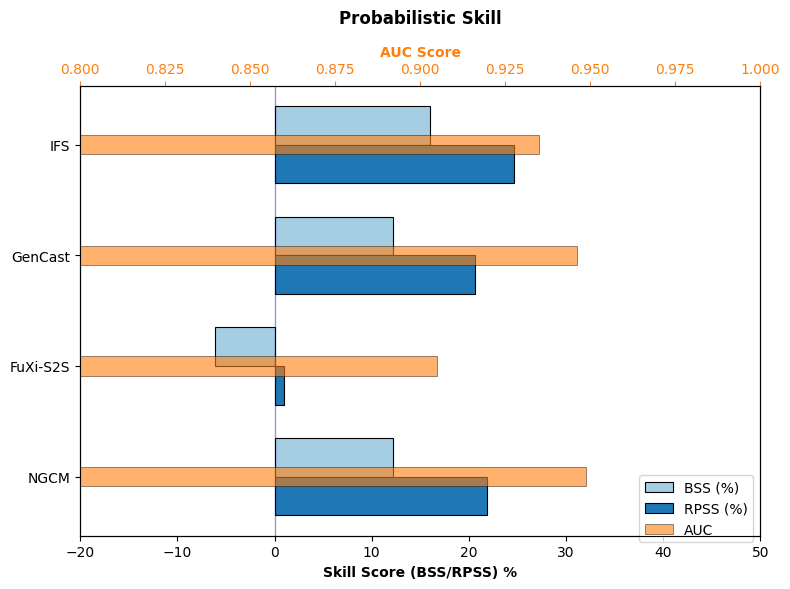

Figure saved as '/Users/christinetsai/winter2026/aice/monsoon-bench/examples/demo_notebooks/outputsprobabilistic_comparison_graph.png'
          fair_brier_skill_score  fair_rps_skill_score  auc_score
model                                                            
IFS                    15.955571             24.697889   0.934997
GenCast                12.184235             20.686710   0.946233
FuXi-S2S               -6.078942              0.928040   0.905029
NGCM                   12.214673             21.858885   0.948857


In [4]:
base_config = {
    # Required arguments
    # Years to process
    "years": [2019, 2020, 2021, 2022, 2023, 2024],
    # Number of ensemble members to use
    "mem_num": 51,
    # Year to use for date filtering
    # cannot include date filter year as a parameter because this messes up calculations
    "date_filter_year": 2024,
    # Directory containing IMD rainfall data
    "imd_folder": f"{data_dir}/imd_rainfall_data/4p0",
    # Path to IMD onset threshold file
    "thres_file": f"{data_dir}/imd_onset_threshold/mwset4x4.nc4",
    # Optional arguments with defaults
    # File pattern for model data
    "file_pattern": "{}.nc",
    # Maximum forecast day (15 or 30)
    "max_forecast_day": 15,
    # Directory to save output files
    "save_dir": output_dir,
    # Use MOK date filter (June 2nd) for onset detection
    "mok": True,
}

# Note: Must do deepcopy to avoid updating base config for other model's inputs
ifs_config = copy.deepcopy(base_config)
ifs_config["mem_num"] = 11

fuxi_config = copy.deepcopy(base_config)
fuxi_config["date_filter_year"] = 2022

model_info = {
    "IFS": {
        "model_forecast_dir": f"{data_dir}/model_forecast_data/IFS-S2S/tp_4p0",
        "config": ifs_config,
    },
    "GenCast": {
        "model_forecast_dir": f"{data_dir}/model_forecast_data/gencast52/tp_lsm_4p0",
        "config": base_config,
    },
    "FuXi-S2S": {
        "model_forecast_dir": f"{data_dir}/model_forecast_data/fuxi_s2s/tp_4p0",
        "config": fuxi_config,
    },
    "NGCM": {
        "model_forecast_dir": f"{data_dir}/model_forecast_data/ngcm51/twice_weekly_0z/tp_4p0",
        "config": base_config,
    },
}

print(compare_probabilistic_models(base_config, model_info))

#### IFS, GenCast, FuXi-S2S, NGCM Models - Period: 2019-2024, 30 day forecast

Processing 124 years: [1901, 1902, 1903, 1904, 1905, 1906, 1907, 1908, 1909, 1910, 1911, 1912, 1913, 1914, 1915, 1916, 1917, 1918, 1919, 1920, 1921, 1922, 1923, 1924, 1925, 1926, 1927, 1928, 1929, 1930, 1931, 1932, 1933, 1934, 1935, 1936, 1937, 1938, 1939, 1940, 1941, 1942, 1943, 1944, 1945, 1946, 1947, 1948, 1949, 1950, 1951, 1952, 1953, 1954, 1955, 1956, 1957, 1958, 1959, 1960, 1961, 1962, 1963, 1964, 1965, 1966, 1967, 1968, 1969, 1970, 1971, 1972, 1973, 1974, 1975, 1976, 1977, 1978, 1979, 1980, 1981, 1982, 1983, 1984, 1985, 1986, 1987, 1988, 1989, 1990, 1991, 1992, 1993, 1994, 1995, 1996, 1997, 1998, 1999, 2000, 2001, 2002, 2003, 2004, 2005, 2006, 2007, 2008, 2009, 2010, 2011, 2012, 2013, 2014, 2015, 2016, 2017, 2018, 2019, 2020, 2021, 2022, 2023, 2024]

Processing year 1901...
Loading IMD rainfall from: /Users/christinetsai/winter2026/aice/monsoon-bench/data/imd_rainfall_data/4p0/1901.nc
Renamed dimensions: {'TIME': 'time'}
Using MOK date (June 2nd) (1901-06-02) as start date for o

Traceback (most recent call last):
  File "/Users/christinetsai/winter2026/aice/monsoon-bench/monsoonbench/metrics/probabilistic.py", line 986, in multi_year_forecast_obs_pairs
    ProbabilisticOnsetMetrics.get_forecast_probabilistic_twice_weekly_2(
    ~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~^
        year,
        ^^^^^
    ...<3 lines>...
        file_pattern,
        ^^^^^^^^^^^^^
    )
    ^
  File "/Users/christinetsai/winter2026/aice/monsoon-bench/monsoonbench/metrics/probabilistic.py", line 104, in get_forecast_probabilistic_twice_weekly_2
    raise FileNotFoundError(f"File not found: {file_path}")
FileNotFoundError: File not found: /Users/christinetsai/winter2026/aice/monsoon-bench/data/model_forecast_data/IFS-S2S/tp_4p0/2024.nc


Generated 1200 climatological forecast-observation pairs
Unique lat-lon pairs processed: 10
Total bins per forecast: 8
Probability range: 0.000 - 1.000
Observed onset rate: 0.125
Non-zero probabilities: 799
Unique locations in output: 10

Distribution across bins:
                      predicted_prob        observed_onset  \
                               count   mean           mean   
bin_label                                                    
After day 30                     150  0.394          0.447   
Before initialization            150  0.109          0.000   
Days 1-5                         150  0.064          0.080   
Days 11-15                       150  0.086          0.093   
Days 16-20                       150  0.087          0.087   
Days 21-25                       150  0.092          0.113   
Days 26-30                       150  0.093          0.080   
Days 6-10                        150  0.074          0.100   

                      n_contributing_years total_mem

Traceback (most recent call last):
  File "/Users/christinetsai/winter2026/aice/monsoon-bench/monsoonbench/metrics/probabilistic.py", line 986, in multi_year_forecast_obs_pairs
    ProbabilisticOnsetMetrics.get_forecast_probabilistic_twice_weekly_2(
    ~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~^
        year,
        ^^^^^
    ...<3 lines>...
        file_pattern,
        ^^^^^^^^^^^^^
    )
    ^
  File "/Users/christinetsai/winter2026/aice/monsoon-bench/monsoonbench/metrics/probabilistic.py", line 104, in get_forecast_probabilistic_twice_weekly_2
    raise FileNotFoundError(f"File not found: {file_path}")
FileNotFoundError: File not found: /Users/christinetsai/winter2026/aice/monsoon-bench/data/model_forecast_data/fuxi_s2s/tp_4p0/2022.nc
Traceback (most recent call last):
  File "/Users/christinetsai/winter2026/aice/monsoon-bench/monsoonbench/metrics/probabilistic.py", line 986, in multi_year_forecast_obs_pairs
    ProbabilisticOnsetMetrics.get_forecast_prob

Generated 1200 climatological forecast-observation pairs
Unique lat-lon pairs processed: 10
Total bins per forecast: 8
Probability range: 0.000 - 1.000
Observed onset rate: 0.125
Non-zero probabilities: 799
Unique locations in output: 10

Distribution across bins:
                      predicted_prob        observed_onset  \
                               count   mean           mean   
bin_label                                                    
After day 30                     150  0.394          0.447   
Before initialization            150  0.109          0.000   
Days 1-5                         150  0.064          0.080   
Days 11-15                       150  0.086          0.093   
Days 16-20                       150  0.087          0.087   
Days 21-25                       150  0.092          0.113   
Days 26-30                       150  0.093          0.080   
Days 6-10                        150  0.074          0.100   

                      n_contributing_years total_mem

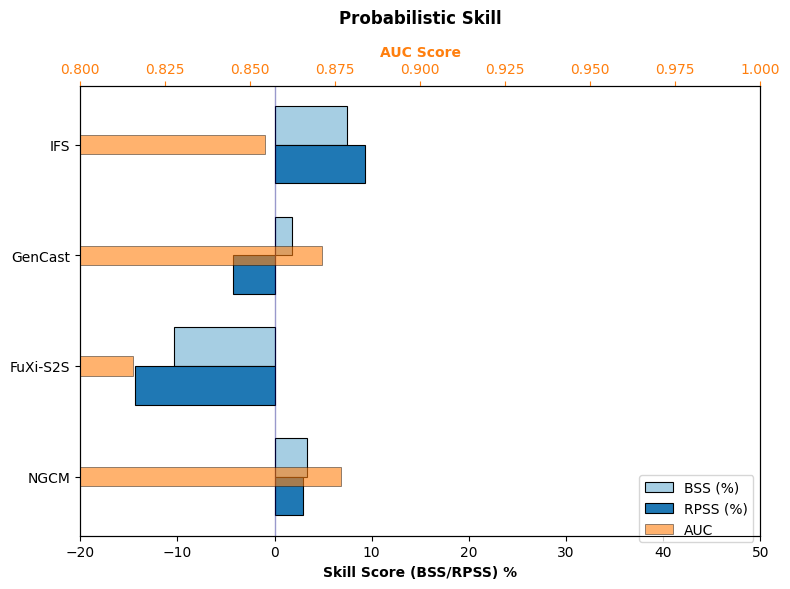

Figure saved as '/Users/christinetsai/winter2026/aice/monsoon-bench/examples/demo_notebooks/outputsprobabilistic_comparison_graph.png'
          fair_brier_skill_score  fair_rps_skill_score  auc_score
model                                                            
IFS                     7.424147              9.287524   0.854224
GenCast                 1.793890             -4.306640   0.870985
FuXi-S2S              -10.378933            -14.338402   0.815478
NGCM                    3.391549              2.970830   0.876835


In [5]:
base_config = {
    # Required arguments
    # Years to process
    "years": [2019, 2020, 2021, 2022, 2023, 2024],
    # Number of ensemble members to use
    "mem_num": 51,
    # Year to use for date filtering
    # cannot include date filter year as a parameter because this messes up calculations
    "date_filter_year": 2024,
    # Directory containing IMD rainfall data
    "imd_folder": f"{data_dir}/imd_rainfall_data/4p0",
    # Path to IMD onset threshold file
    "thres_file": f"{data_dir}/imd_onset_threshold/mwset4x4.nc4",
    # Optional arguments with defaults
    # File pattern for model data
    "file_pattern": "{}.nc",
    # Maximum forecast day (15 or 30)
    "max_forecast_day": 30,
    # Directory to save output files
    "save_dir": output_dir,
    # Use MOK date filter (June 2nd) for onset detection
    "mok": True,
}

ifs_config = copy.deepcopy(base_config)
ifs_config["mem_num"] = 11

fuxi_config = copy.deepcopy(base_config)
fuxi_config["date_filter_year"] = 2022

model_info = {
    "IFS": {
        "model_forecast_dir": f"{data_dir}/model_forecast_data/IFS-S2S/tp_4p0",
        "config": ifs_config,
    },
    "GenCast": {
        "model_forecast_dir": f"{data_dir}/model_forecast_data/gencast52/tp_lsm_4p0",
        "config": base_config,
    },
    "FuXi-S2S": {
        "model_forecast_dir": f"{data_dir}/model_forecast_data/fuxi_s2s/tp_4p0",
        "config": fuxi_config,
    },
    "NGCM": {
        "model_forecast_dir": f"{data_dir}/model_forecast_data/ngcm51/twice_weekly_0z/tp_4p0",
        "config": base_config,
    },
}

print(compare_probabilistic_models(base_config, model_info))

#### IFS, FuXi-S2S, NGCM Models - Period: 2004-2021, 15 day forecast

Processing 124 years: [1901, 1902, 1903, 1904, 1905, 1906, 1907, 1908, 1909, 1910, 1911, 1912, 1913, 1914, 1915, 1916, 1917, 1918, 1919, 1920, 1921, 1922, 1923, 1924, 1925, 1926, 1927, 1928, 1929, 1930, 1931, 1932, 1933, 1934, 1935, 1936, 1937, 1938, 1939, 1940, 1941, 1942, 1943, 1944, 1945, 1946, 1947, 1948, 1949, 1950, 1951, 1952, 1953, 1954, 1955, 1956, 1957, 1958, 1959, 1960, 1961, 1962, 1963, 1964, 1965, 1966, 1967, 1968, 1969, 1970, 1971, 1972, 1973, 1974, 1975, 1976, 1977, 1978, 1979, 1980, 1981, 1982, 1983, 1984, 1985, 1986, 1987, 1988, 1989, 1990, 1991, 1992, 1993, 1994, 1995, 1996, 1997, 1998, 1999, 2000, 2001, 2002, 2003, 2004, 2005, 2006, 2007, 2008, 2009, 2010, 2011, 2012, 2013, 2014, 2015, 2016, 2017, 2018, 2019, 2020, 2021, 2022, 2023, 2024]

Processing year 1901...
Loading IMD rainfall from: /Users/christinetsai/winter2026/aice/monsoon-bench/data/imd_rainfall_data/4p0/1901.nc
Renamed dimensions: {'TIME': 'time'}
Using MOK date (June 2nd) (1901-06-02) as start date for o

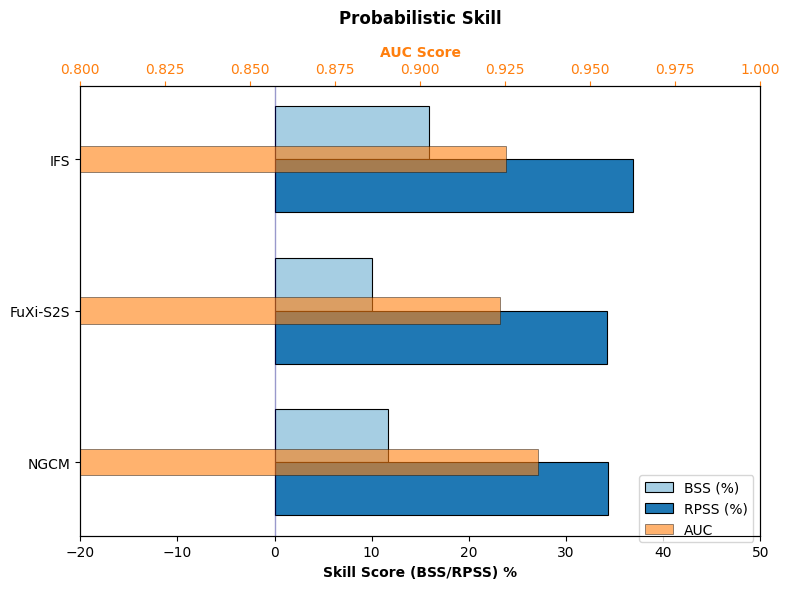

Figure saved as '/Users/christinetsai/winter2026/aice/monsoon-bench/examples/demo_notebooks/outputsprobabilistic_comparison_graph.png'
          fair_brier_skill_score  fair_rps_skill_score  auc_score
model                                                            
IFS                    15.862001             36.928713   0.925129
FuXi-S2S               10.037651             34.251454   0.923466
NGCM                   11.732468             34.340202   0.934532


In [6]:
base_config = {
    # Required arguments
    # Years to process
    "years": [
        2004,
        2005,
        2006,
        2007,
        2008,
        2009,
        2010,
        2011,
        2012,
        2013,
        2014,
        2015,
        2016,
        2017,
        2018,
        2019,
        2020,
        2021,
    ],
    # Number of ensemble members to use
    "mem_num": 51,
    # Year to use for date filtering
    "date_filter_year": 2024,
    # Directory containing IMD rainfall data
    "imd_folder": f"{data_dir}/imd_rainfall_data/4p0",
    # Path to IMD onset threshold file
    "thres_file": f"{data_dir}/imd_onset_threshold/mwset4x4.nc4",
    # Optional arguments with defaults
    # File pattern for model data
    "file_pattern": "{}.nc",
    # Maximum forecast day (15 or 30)
    "max_forecast_day": 15,
    # Directory to save output files
    "save_dir": output_dir,
    # Use MOK date filter (June 2nd) for onset detection
    "mok": True,
}

ifs_config = copy.deepcopy(base_config)
ifs_config["mem_num"] = 11

fuxi_config = copy.deepcopy(base_config)
fuxi_config["date_filter_year"] = 2022

model_info = {
    "IFS": {
        "model_forecast_dir": f"{data_dir}/model_forecast_data/IFS-S2S/tp_4p0",
        "config": ifs_config,
    },
    "FuXi-S2S": {
        "model_forecast_dir": f"{data_dir}/model_forecast_data/fuxi_s2s/tp_4p0",
        "config": fuxi_config,
    },
    "NGCM": {
        "model_forecast_dir": f"{data_dir}/model_forecast_data/ngcm51/twice_weekly_0z/tp_4p0",
        "config": base_config,
    },
}

print(compare_probabilistic_models(base_config, model_info))

#### IFS, FuXi-S2S, NGCM Models - Period: 2004-2021, 30 day forecast

Processing 124 years: [1901, 1902, 1903, 1904, 1905, 1906, 1907, 1908, 1909, 1910, 1911, 1912, 1913, 1914, 1915, 1916, 1917, 1918, 1919, 1920, 1921, 1922, 1923, 1924, 1925, 1926, 1927, 1928, 1929, 1930, 1931, 1932, 1933, 1934, 1935, 1936, 1937, 1938, 1939, 1940, 1941, 1942, 1943, 1944, 1945, 1946, 1947, 1948, 1949, 1950, 1951, 1952, 1953, 1954, 1955, 1956, 1957, 1958, 1959, 1960, 1961, 1962, 1963, 1964, 1965, 1966, 1967, 1968, 1969, 1970, 1971, 1972, 1973, 1974, 1975, 1976, 1977, 1978, 1979, 1980, 1981, 1982, 1983, 1984, 1985, 1986, 1987, 1988, 1989, 1990, 1991, 1992, 1993, 1994, 1995, 1996, 1997, 1998, 1999, 2000, 2001, 2002, 2003, 2004, 2005, 2006, 2007, 2008, 2009, 2010, 2011, 2012, 2013, 2014, 2015, 2016, 2017, 2018, 2019, 2020, 2021, 2022, 2023, 2024]

Processing year 1901...
Loading IMD rainfall from: /Users/christinetsai/winter2026/aice/monsoon-bench/data/imd_rainfall_data/4p0/1901.nc
Renamed dimensions: {'TIME': 'time'}
Using MOK date (June 2nd) (1901-06-02) as start date for o

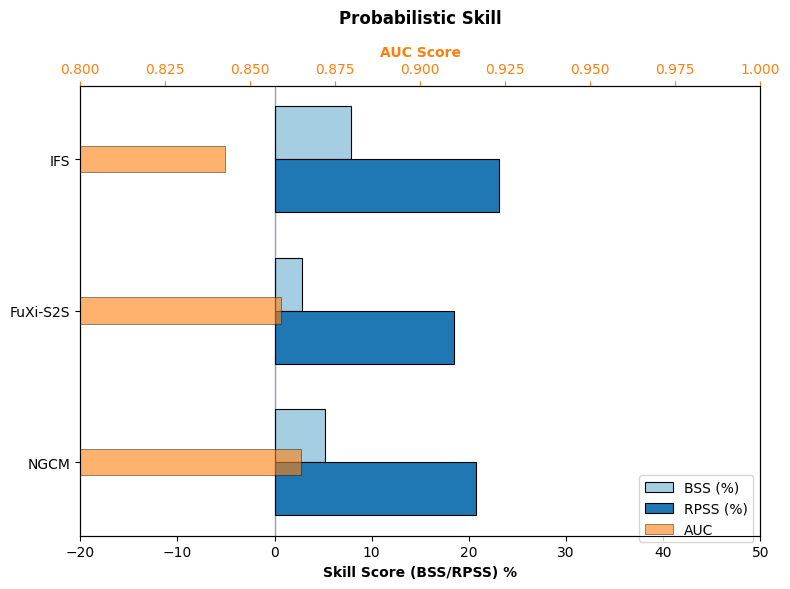

Figure saved as '/Users/christinetsai/winter2026/aice/monsoon-bench/examples/demo_notebooks/outputsprobabilistic_comparison_graph.png'
          fair_brier_skill_score  fair_rps_skill_score  auc_score
model                                                            
IFS                     7.863738             23.069600   0.842629
FuXi-S2S                2.857480             18.435361   0.859158
NGCM                    5.223748             20.735958   0.864942


In [7]:
base_config = {
    # Required arguments
    # Years to process
    "years": [
        2004,
        2005,
        2006,
        2007,
        2008,
        2009,
        2010,
        2011,
        2012,
        2013,
        2014,
        2015,
        2016,
        2017,
        2018,
        2019,
        2020,
        2021,
    ],
    # Number of ensemble members to use
    "mem_num": 51,
    # Year to use for date filtering
    "date_filter_year": 2024,
    # Directory containing IMD rainfall data
    "imd_folder": f"{data_dir}/imd_rainfall_data/4p0",
    # Path to IMD onset threshold file
    "thres_file": f"{data_dir}/imd_onset_threshold/mwset4x4.nc4",
    # Optional arguments with defaults
    # File pattern for model data
    "file_pattern": "{}.nc",
    # Maximum forecast day (15 or 30)
    "max_forecast_day": 30,
    # Directory to save output files
    "save_dir": output_dir,
    # Use MOK date filter (June 2nd) for onset detection
    "mok": True,
}

ifs_config = copy.deepcopy(base_config)
ifs_config["mem_num"] = 11

fuxi_config = copy.deepcopy(base_config)
fuxi_config["date_filter_year"] = 2022

model_info = {
    "IFS": {
        "model_forecast_dir": f"{data_dir}/model_forecast_data/IFS-S2S/tp_4p0",
        "config": ifs_config,
    },
    "FuXi-S2S": {
        "model_forecast_dir": f"{data_dir}/model_forecast_data/fuxi_s2s/tp_4p0",
        "config": fuxi_config,
    },
    "NGCM": {
        "model_forecast_dir": f"{data_dir}/model_forecast_data/ngcm51/twice_weekly_0z/tp_4p0",
        "config": base_config,
    },
}

print(compare_probabilistic_models(base_config, model_info))

## Reliability Diagrams

In [3]:
base_config = {
    # Required arguments
    # Directory containing IMD rainfall data
    "imd_folder": f"{data_dir}/imd_rainfall_data/4p0",
    # Path to threshold NetCDF file
    "thres_file": f"{data_dir}/imd_onset_threshold/mwset4x4.nc4",
    # Number of ensemble members to use
    "mem_num": 11,
    # Optional arguments
    # File pattern for data
    "file_pattern": "{}.nc",
    # Maximum forecast day (15 or 30)
    "max_forecast_day": 15,
    # Directory to save output CSV and PNG files
    "save_dir": output_dir,
    # Use MOK date filter (June 2nd) for onset detection
    "mok": True,
}

### IFS Model: Period 2019-2024, 1-15 day forecast

S2S MONSOON ONSET SKILL SCORE ANALYSIS
Model: ifs | Years: [2019, 2020, 2021, 2022, 2023]
Processing years: [2019, 2020, 2021, 2022, 2023]
Using 4-degree CMZ polygon coordinates

Processing year 2019
Loading S2S model data...
Loading IMD rainfall data...
Loading IMD rainfall from: /Users/christinetsai/winter2026/aice/monsoon-bench/data/imd_rainfall_data/4p0/2019.nc
Renamed dimensions: {'TIME': 'time'}
Detecting observed onset...
Using MOK date (June 2nd) (2019-06-02) as start date for onset detection
Found onset in 100 out of 100 grid points
Computing onset for all ensemble members...
Processing 26 init times x 10 unique locations x 11 members...
Unique lat-lon pairs: [(np.float64(76.0), np.float64(20.0)), (np.float64(80.0), np.float64(20.0)), (np.float64(84.0), np.float64(20.0)), (np.float64(72.0), np.float64(24.0)), (np.float64(76.0), np.float64(24.0)), (np.float64(80.0), np.float64(24.0)), (np.float64(84.0), np.float64(24.0)), (np.float64(72.0), np.float64(28.0)), (np.float64(76.0),

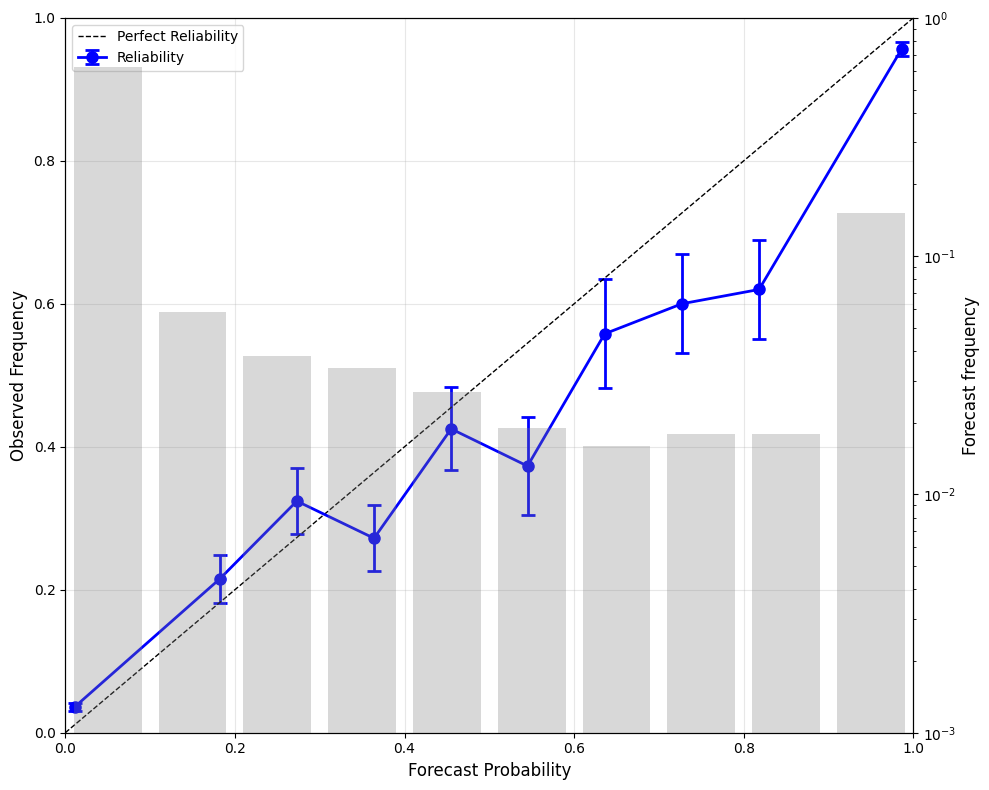

,Bin_Range,N_Forecasts,Mean_Forecast_Prob,Observed_Frequency,Frequency,Error_Bar,bin_center
0,0.0-0.1,1678,0.011,0.036,0.621,0.005,0.05
1,0.1-0.2,158,0.182,0.215,0.058,0.033,0.15
2,0.2-0.3,102,0.273,0.324,0.038,0.046,0.25
3,0.3-0.4,92,0.364,0.272,0.034,0.046,0.35
4,0.4-0.5,73,0.455,0.425,0.027,0.058,0.45
5,0.5-0.6,51,0.545,0.373,0.019,0.068,0.55
6,0.6-0.7,43,0.636,0.558,0.016,0.076,0.65
7,0.7-0.8,50,0.727,0.600,0.018,0.069,0.75
8,0.8-0.9,50,0.818,0.620,0.018,0.069,0.85
9,0.9-1.0,407,0.986,0.956,0.151,0.010,0.95


In [11]:
model_config = {
    # Directory containing model forecast data.
    "model_forecast_dir": f"{data_dir}/model_forecast_data/IFS-S2S/tp_4p0",
    # Model name for output files
    "model_name": "ifs",
    # Number of ensemble members to use
    "mem_num": 11,
    # Years to process
    "years": [2019, 2020, 2021, 2022, 2023],
    # Year to use for date filtering
    "date_filter_year": 2024,
}
config = base_config | model_config
run_reliability_analysis(config)

### IFS Model: Period 2004-2021, 1-15 day forecast

S2S MONSOON ONSET SKILL SCORE ANALYSIS
Model: ifs | Years: [2004, 2005, 2006, 2007, 2008, 2009, 2010, 2011, 2012, 2013, 2014, 2015, 2016, 2017, 2018, 2019, 2020, 2021]
Processing years: [2004, 2005, 2006, 2007, 2008, 2009, 2010, 2011, 2012, 2013, 2014, 2015, 2016, 2017, 2018, 2019, 2020, 2021]
Using 4-degree CMZ polygon coordinates

Processing year 2004
Loading S2S model data...
Loading IMD rainfall data...
Loading IMD rainfall from: /Users/christinetsai/winter2026/aice/monsoon-bench/data/imd_rainfall_data/4p0/2004.nc
Renamed dimensions: {'TIME': 'time'}
Detecting observed onset...
Using MOK date (June 2nd) (2004-06-02) as start date for onset detection
Found onset in 100 out of 100 grid points
Computing onset for all ensemble members...
Processing 26 init times x 10 unique locations x 11 members...
Unique lat-lon pairs: [(np.float64(76.0), np.float64(20.0)), (np.float64(80.0), np.float64(20.0)), (np.float64(84.0), np.float64(20.0)), (np.float64(72.0), np.float64(24.0)), (np.float64(76

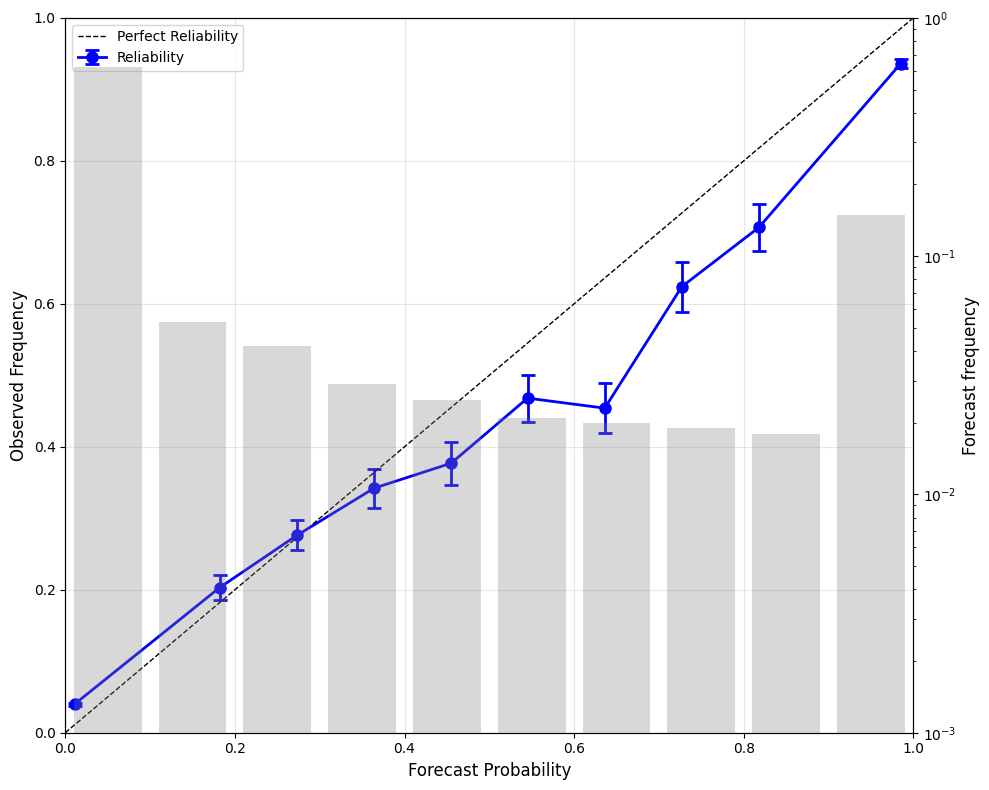

,Bin_Range,N_Forecasts,Mean_Forecast_Prob,Observed_Frequency,Frequency,Error_Bar,bin_center
0,0.0-0.1,6500,0.011,0.040,0.623,0.002,0.05
1,0.1-0.2,557,0.182,0.203,0.053,0.017,0.15
2,0.2-0.3,442,0.273,0.276,0.042,0.021,0.25
3,0.3-0.4,304,0.364,0.342,0.029,0.027,0.35
4,0.4-0.5,265,0.455,0.377,0.025,0.030,0.45
5,0.5-0.6,222,0.545,0.468,0.021,0.033,0.55
6,0.6-0.7,207,0.636,0.454,0.020,0.035,0.65
7,0.7-0.8,194,0.727,0.624,0.019,0.035,0.75
8,0.8-0.9,191,0.818,0.707,0.018,0.033,0.85
9,0.9-1.0,1558,0.985,0.936,0.149,0.006,0.95


In [10]:
model_config = {
    # Directory containing model forecast data.
    "model_forecast_dir": f"{data_dir}/model_forecast_data/IFS-S2S/tp_4p0",
    # Model name for output files
    "model_name": "ifs",
    # Number of ensemble members to use
    "mem_num": 11,
    # Years to process
    "years": [
        2004,
        2005,
        2006,
        2007,
        2008,
        2009,
        2010,
        2011,
        2012,
        2013,
        2014,
        2015,
        2016,
        2017,
        2018,
        2019,
        2020,
        2021,
    ],
    # Year to use for date filtering
    "date_filter_year": 2024,
}
config = base_config | model_config
run_reliability_analysis(config)

### GenCast Model: Period 2019-2024

S2S MONSOON ONSET SKILL SCORE ANALYSIS
Model: gencast | Years: [2019, 2020, 2021, 2022, 2023, 2024]
Processing years: [2019, 2020, 2021, 2022, 2023, 2024]
Using 4-degree CMZ polygon coordinates

Processing year 2019
Loading S2S model data...
Loading IMD rainfall data...
Loading IMD rainfall from: /Users/christinetsai/winter2026/aice/monsoon-bench/data/imd_rainfall_data/4p0/2019.nc
Renamed dimensions: {'TIME': 'time'}
Detecting observed onset...
Using MOK date (June 2nd) (2019-06-02) as start date for onset detection
Found onset in 100 out of 100 grid points
Computing onset for all ensemble members...
Processing 26 init times x 10 unique locations x 51 members...
Unique lat-lon pairs: [(np.float64(76.0), np.float64(20.0)), (np.float64(80.0), np.float64(20.0)), (np.float64(84.0), np.float64(20.0)), (np.float64(72.0), np.float64(24.0)), (np.float64(76.0), np.float64(24.0)), (np.float64(80.0), np.float64(24.0)), (np.float64(84.0), np.float64(24.0)), (np.float64(72.0), np.float64(28.0)), (n

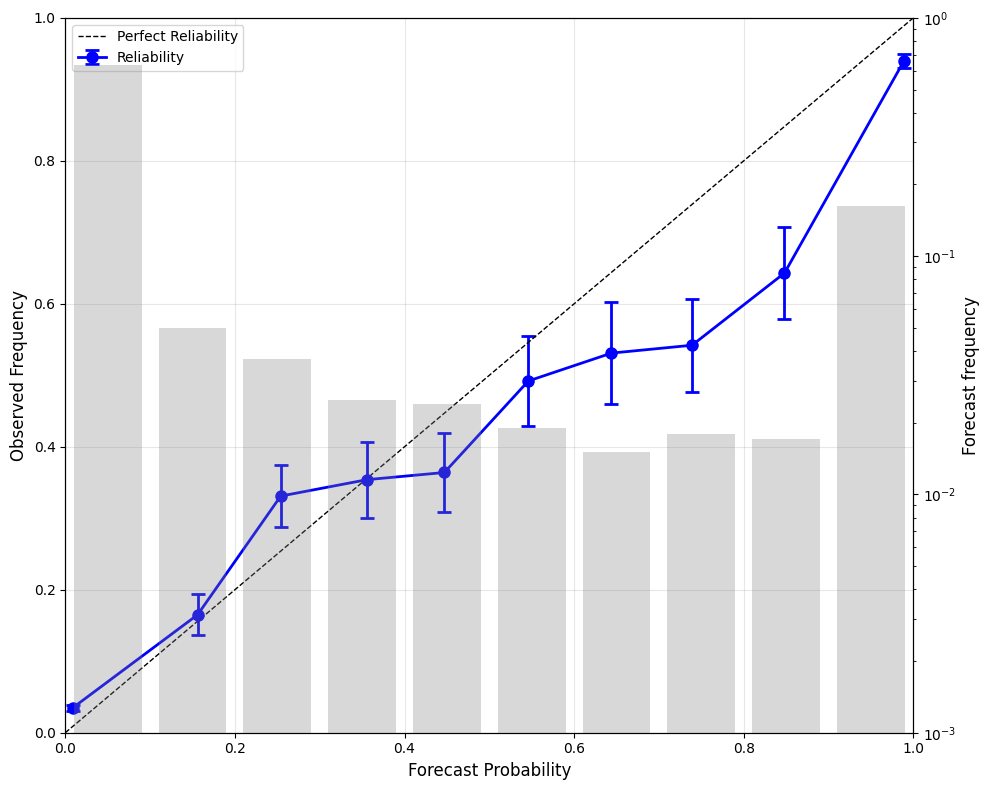

,Bin_Range,N_Forecasts,Mean_Forecast_Prob,Observed_Frequency,Frequency,Error_Bar,bin_center
0,0.0-0.1,2075,0.009,0.035,0.633,0.004,0.05
1,0.1-0.2,164,0.156,0.165,0.050,0.029,0.15
2,0.2-0.3,121,0.254,0.331,0.037,0.043,0.25
3,0.3-0.4,82,0.356,0.354,0.025,0.053,0.35
4,0.4-0.5,77,0.447,0.364,0.024,0.055,0.45
5,0.5-0.6,63,0.546,0.492,0.019,0.063,0.55
6,0.6-0.7,49,0.644,0.531,0.015,0.071,0.65
7,0.7-0.8,59,0.739,0.542,0.018,0.065,0.75
8,0.8-0.9,56,0.848,0.643,0.017,0.064,0.85
9,0.9-1.0,530,0.989,0.940,0.162,0.010,0.95


In [9]:
model_config = {
    # Directory containing model forecast data.
    "model_forecast_dir": f"{data_dir}/model_forecast_data/gencast52/tp_lsm_4p0",
    # Model name for output files
    "model_name": "gencast",
    # Number of ensemble members to use
    "mem_num": 51,
    # Years to process
    "years": [2019, 2020, 2021, 2022, 2023, 2024],
    # Year to use for date filtering
    "date_filter_year": 2024,
}
config = base_config | model_config
run_reliability_analysis(config)

### FuXi-S2S Model: Period 2019-2024

S2S MONSOON ONSET SKILL SCORE ANALYSIS
Model: fuxi-s2s | Years: [2019, 2020, 2021]
Processing years: [2019, 2020, 2021]
Using 4-degree CMZ polygon coordinates

Processing year 2019
Loading S2S model data...
Loading IMD rainfall data...
Loading IMD rainfall from: /Users/christinetsai/winter2026/aice/monsoon-bench/data/imd_rainfall_data/4p0/2019.nc
Renamed dimensions: {'TIME': 'time'}
Detecting observed onset...
Using MOK date (June 2nd) (2019-06-02) as start date for onset detection
Found onset in 100 out of 100 grid points
Computing onset for all ensemble members...
Processing 26 init times x 10 unique locations x 51 members...
Unique lat-lon pairs: [(np.float64(76.0), np.float64(20.0)), (np.float64(80.0), np.float64(20.0)), (np.float64(84.0), np.float64(20.0)), (np.float64(72.0), np.float64(24.0)), (np.float64(76.0), np.float64(24.0)), (np.float64(80.0), np.float64(24.0)), (np.float64(84.0), np.float64(24.0)), (np.float64(72.0), np.float64(28.0)), (np.float64(76.0), np.float64(28.0)),

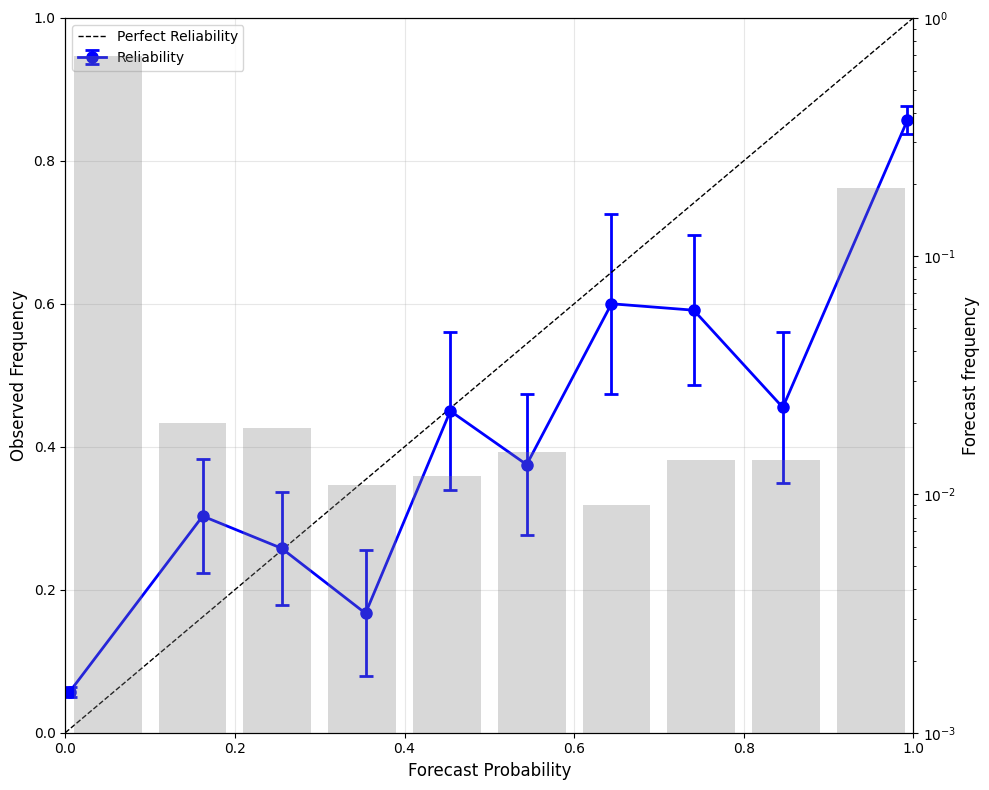

,Bin_Range,N_Forecasts,Mean_Forecast_Prob,Observed_Frequency,Frequency,Error_Bar,bin_center
0,0.0-0.1,1117,0.005,0.057,0.691,0.007,0.05
1,0.1-0.2,33,0.162,0.303,0.020,0.080,0.15
2,0.2-0.3,31,0.255,0.258,0.019,0.079,0.25
3,0.3-0.4,18,0.354,0.167,0.011,0.088,0.35
4,0.4-0.5,20,0.454,0.450,0.012,0.111,0.45
5,0.5-0.6,24,0.544,0.375,0.015,0.099,0.55
6,0.6-0.7,15,0.644,0.600,0.009,0.126,0.65
7,0.7-0.8,22,0.741,0.591,0.014,0.105,0.75
8,0.8-0.9,22,0.846,0.455,0.014,0.106,0.85
9,0.9-1.0,314,0.993,0.857,0.194,0.020,0.95


In [8]:
model_config = {
    # Directory containing model forecast data.
    "model_forecast_dir": f"{data_dir}/model_forecast_data/fuxi_s2s/tp_4p0",
    # Model name for output files
    "model_name": "fuxi-s2s",
    # Number of ensemble members to use
    "mem_num": 51,
    # Years to process
    "years": [2019, 2020, 2021],
    # Year to use for date filtering
    "date_filter_year": 2022,
}
config = base_config | model_config
run_reliability_analysis(config)

### FuXi-S2S Model: Period 2004-2021

S2S MONSOON ONSET SKILL SCORE ANALYSIS
Model: fuxi-s2s | Years: [2004, 2005, 2006, 2007, 2008, 2009, 2010, 2011, 2012, 2013, 2014, 2015, 2016, 2017, 2018, 2019, 2020, 2021]
Processing years: [2004, 2005, 2006, 2007, 2008, 2009, 2010, 2011, 2012, 2013, 2014, 2015, 2016, 2017, 2018, 2019, 2020, 2021]
Using 4-degree CMZ polygon coordinates

Processing year 2004
Loading S2S model data...
Loading IMD rainfall data...
Loading IMD rainfall from: /Users/christinetsai/winter2026/aice/monsoon-bench/data/imd_rainfall_data/4p0/2004.nc
Renamed dimensions: {'TIME': 'time'}
Detecting observed onset...
Using MOK date (June 2nd) (2004-06-02) as start date for onset detection
Found onset in 100 out of 100 grid points
Computing onset for all ensemble members...
Processing 26 init times x 10 unique locations x 51 members...
Unique lat-lon pairs: [(np.float64(76.0), np.float64(20.0)), (np.float64(80.0), np.float64(20.0)), (np.float64(84.0), np.float64(20.0)), (np.float64(72.0), np.float64(24.0)), (np.float

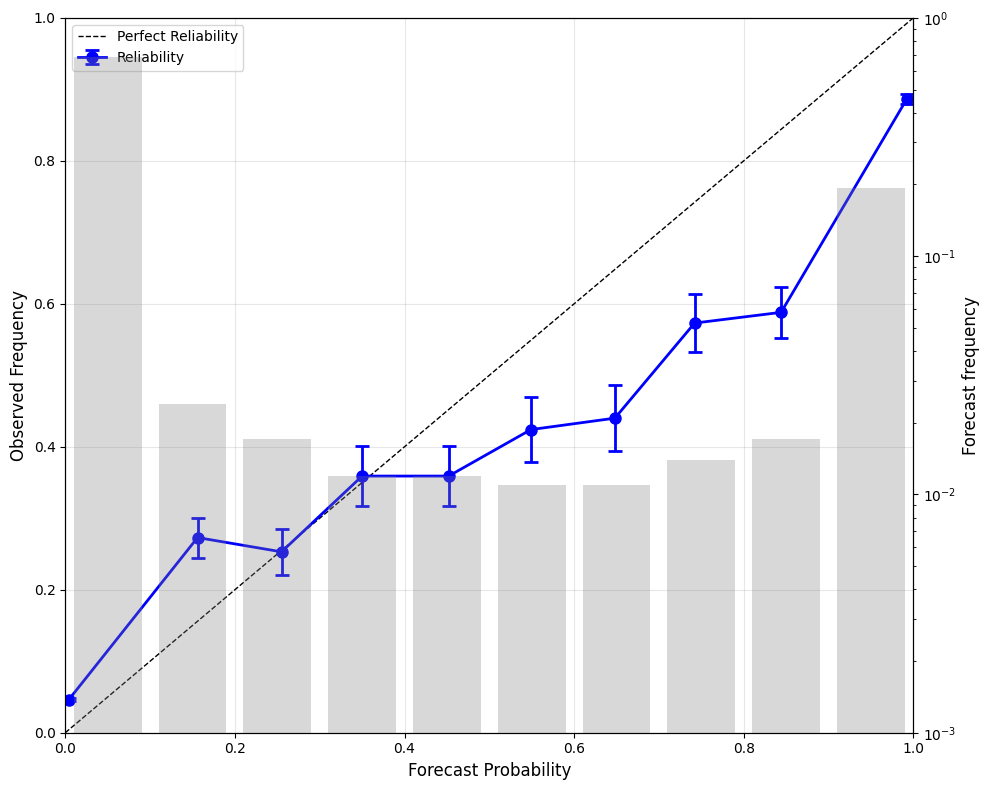

,Bin_Range,N_Forecasts,Mean_Forecast_Prob,Observed_Frequency,Frequency,Error_Bar,bin_center
0,0.0-0.1,7286,0.004,0.046,0.688,0.002,0.05
1,0.1-0.2,256,0.156,0.273,0.024,0.028,0.15
2,0.2-0.3,182,0.255,0.253,0.017,0.032,0.25
3,0.3-0.4,128,0.350,0.359,0.012,0.042,0.35
4,0.4-0.5,131,0.452,0.359,0.012,0.042,0.45
5,0.5-0.6,118,0.549,0.424,0.011,0.045,0.55
6,0.6-0.7,116,0.648,0.440,0.011,0.046,0.65
7,0.7-0.8,143,0.742,0.573,0.014,0.041,0.75
8,0.8-0.9,182,0.844,0.588,0.017,0.036,0.85
9,0.9-1.0,2042,0.992,0.886,0.193,0.007,0.95


In [7]:
model_config = {
    # Directory containing model forecast data.
    "model_forecast_dir": f"{data_dir}/model_forecast_data/fuxi_s2s/tp_4p0",
    # Model name for output files
    "model_name": "fuxi-s2s",
    # Number of ensemble members to use
    "mem_num": 51,
    # Years to process
    "years": [
        2004,
        2005,
        2006,
        2007,
        2008,
        2009,
        2010,
        2011,
        2012,
        2013,
        2014,
        2015,
        2016,
        2017,
        2018,
        2019,
        2020,
        2021,
    ],
    # Year to use for date filtering
    "date_filter_year": 2022,
}
config = base_config | model_config
run_reliability_analysis(config)

### NGCM Climatology Model: Period 2019-2024

S2S MONSOON ONSET SKILL SCORE ANALYSIS
Model: ngcm | Years: [2019, 2020, 2021, 2022, 2023, 2024]
Processing years: [2019, 2020, 2021, 2022, 2023, 2024]
Using 4-degree CMZ polygon coordinates

Processing year 2019
Loading S2S model data...
Loading IMD rainfall data...
Loading IMD rainfall from: /Users/christinetsai/winter2026/aice/monsoon-bench/data/imd_rainfall_data/4p0/2019.nc
Renamed dimensions: {'TIME': 'time'}
Detecting observed onset...
Using MOK date (June 2nd) (2019-06-02) as start date for onset detection
Found onset in 100 out of 100 grid points
Computing onset for all ensemble members...
Processing 26 init times x 10 unique locations x 51 members...
Unique lat-lon pairs: [(np.float64(76.0), np.float64(20.0)), (np.float64(80.0), np.float64(20.0)), (np.float64(84.0), np.float64(20.0)), (np.float64(72.0), np.float64(24.0)), (np.float64(76.0), np.float64(24.0)), (np.float64(80.0), np.float64(24.0)), (np.float64(84.0), np.float64(24.0)), (np.float64(72.0), np.float64(28.0)), (np.f

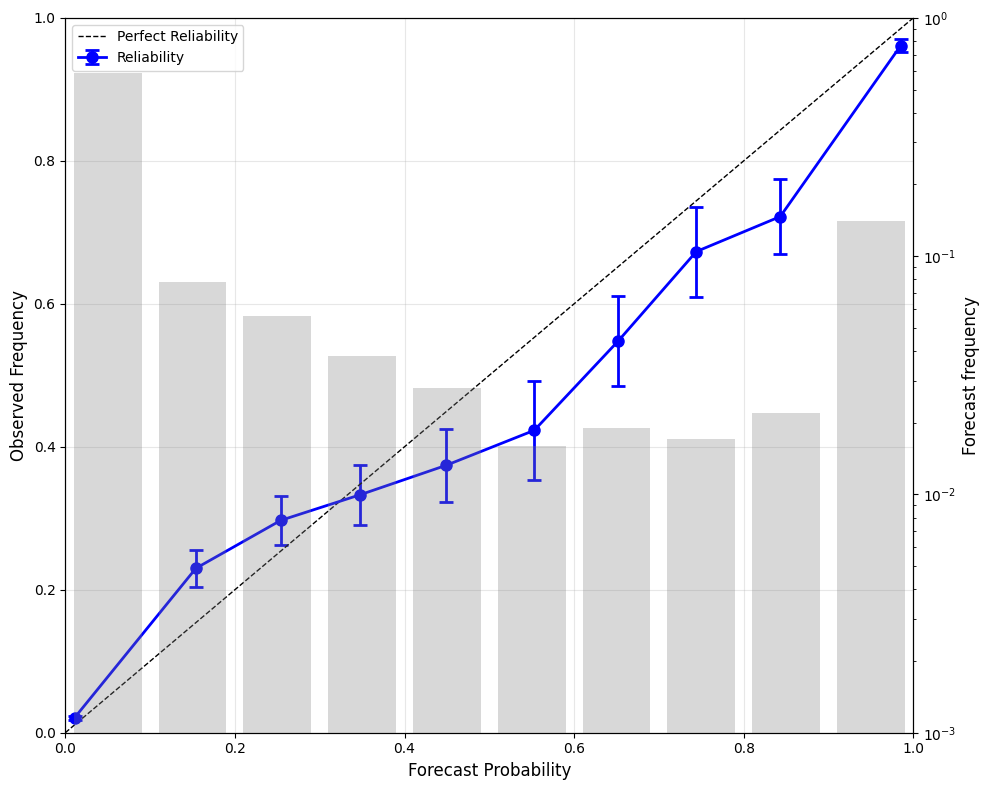

,Bin_Range,N_Forecasts,Mean_Forecast_Prob,Observed_Frequency,Frequency,Error_Bar,bin_center
0,0.0-0.1,1914,0.011,0.021,0.584,0.003,0.05
1,0.1-0.2,257,0.154,0.230,0.078,0.026,0.15
2,0.2-0.3,185,0.254,0.297,0.056,0.034,0.25
3,0.3-0.4,126,0.348,0.333,0.038,0.042,0.35
4,0.4-0.5,91,0.449,0.374,0.028,0.051,0.45
5,0.5-0.6,52,0.553,0.423,0.016,0.069,0.55
6,0.6-0.7,62,0.652,0.548,0.019,0.063,0.65
7,0.7-0.8,55,0.744,0.673,0.017,0.063,0.75
8,0.8-0.9,72,0.843,0.722,0.022,0.053,0.85
9,0.9-1.0,462,0.985,0.961,0.141,0.009,0.95


In [6]:
model_config = {
    # Directory containing model forecast data.
    "model_forecast_dir": f"{data_dir}/model_forecast_data/ngcm51/climatology/tp_4p0",
    # Model name for output files
    "model_name": "ngcm",
    # Number of ensemble members to use
    "mem_num": 51,
    # Years to process
    "years": [2019, 2020, 2021, 2022, 2023, 2024],
    # Year to use for date filtering
    "date_filter_year": 2024,
}
config = base_config | model_config
run_reliability_analysis(config)

### NGCM Climatology Model: Period 2004-2021

S2S MONSOON ONSET SKILL SCORE ANALYSIS
Model: ngcm | Years: [2004, 2005, 2006, 2007, 2008, 2009, 2010, 2011, 2012, 2013, 2014, 2015, 2016, 2017, 2018, 2019, 2020, 2021]
Processing years: [2004, 2005, 2006, 2007, 2008, 2009, 2010, 2011, 2012, 2013, 2014, 2015, 2016, 2017, 2018, 2019, 2020, 2021]
Using 4-degree CMZ polygon coordinates

Processing year 2004
Loading S2S model data...
Loading IMD rainfall data...
Loading IMD rainfall from: /Users/christinetsai/winter2026/aice/monsoon-bench/data/imd_rainfall_data/4p0/2004.nc
Renamed dimensions: {'TIME': 'time'}
Detecting observed onset...
Using MOK date (June 2nd) (2004-06-02) as start date for onset detection
Found onset in 100 out of 100 grid points
Computing onset for all ensemble members...
Processing 26 init times x 10 unique locations x 51 members...
Unique lat-lon pairs: [(np.float64(76.0), np.float64(20.0)), (np.float64(80.0), np.float64(20.0)), (np.float64(84.0), np.float64(20.0)), (np.float64(72.0), np.float64(24.0)), (np.float64(7

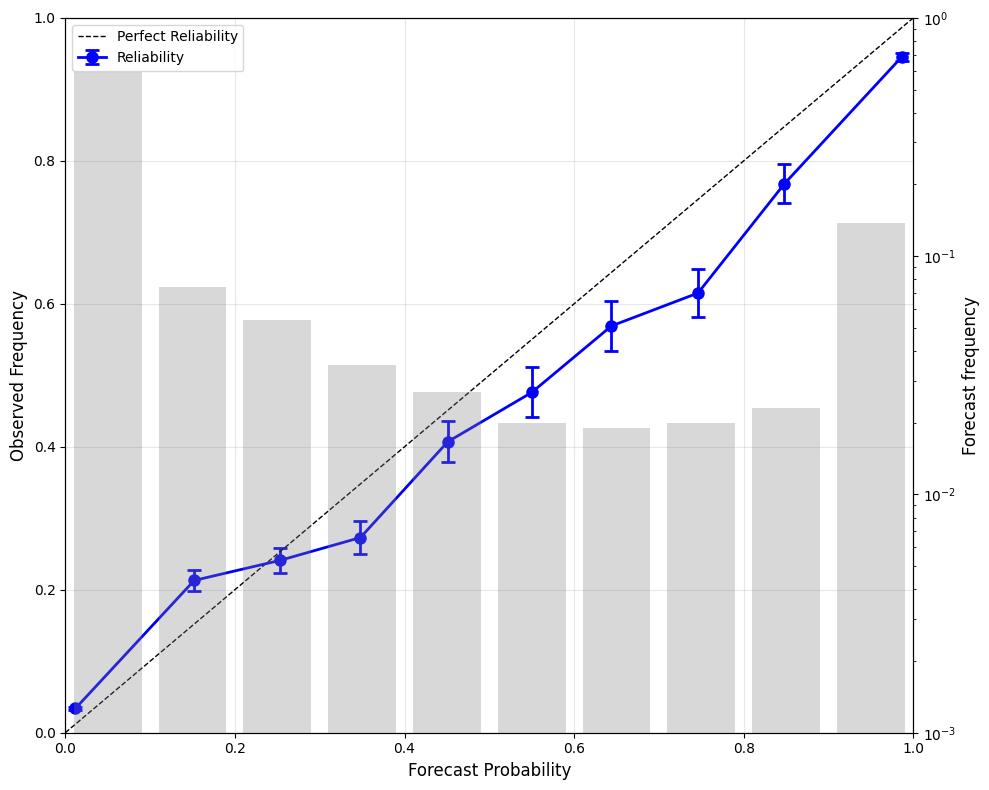

,Bin_Range,N_Forecasts,Mean_Forecast_Prob,Observed_Frequency,Frequency,Error_Bar,bin_center
0,0.0-0.1,6163,0.012,0.034,0.590,0.002,0.05
1,0.1-0.2,769,0.152,0.213,0.074,0.015,0.15
2,0.2-0.3,561,0.253,0.241,0.054,0.018,0.25
3,0.3-0.4,363,0.348,0.273,0.035,0.023,0.35
4,0.4-0.5,285,0.451,0.407,0.027,0.029,0.45
5,0.5-0.6,206,0.550,0.476,0.020,0.035,0.55
6,0.6-0.7,202,0.644,0.569,0.019,0.035,0.65
7,0.7-0.8,213,0.746,0.615,0.020,0.033,0.75
8,0.8-0.9,241,0.848,0.768,0.023,0.027,0.85
9,0.9-1.0,1437,0.986,0.945,0.138,0.006,0.95


In [5]:
model_config = {
    # Directory containing model forecast data.
    "model_forecast_dir": f"{data_dir}/model_forecast_data/ngcm51/climatology/tp_4p0",
    # Model name for output files
    "model_name": "ngcm",
    # Number of ensemble members to use
    "mem_num": 51,
    # Years to process
    "years": [
        2004,
        2005,
        2006,
        2007,
        2008,
        2009,
        2010,
        2011,
        2012,
        2013,
        2014,
        2015,
        2016,
        2017,
        2018,
        2019,
        2020,
        2021,
    ],
    # Year to use for date filtering
    "date_filter_year": 2024,
}
config = base_config | model_config
run_reliability_analysis(config)